<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_6_regressao_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [23]:
# Baixe o dataset de preço dos imóveis da California
housing = fetch_california_housing()
df_real = pd.DataFrame(housing.data, columns=housing.feature_names)
df_real['MEDV'] = housing.target
display(df_real.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MEDV
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [24]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [25]:
modelo_nivel_nivel = smf.ols('MEDV ~ MedInc + HouseAge + AveRooms', data=df_real).fit()
print(modelo_nivel_nivel.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     7220.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:00:01   Log-Likelihood:                -24836.
No. Observations:               20640   AIC:                         4.968e+04
Df Residuals:                   20636   BIC:                         4.971e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0204      0.022      0.928      0.3

In [26]:
# Ajuste do modelo Nível-Log (variável dependente em log)
modelo_nivellog = smf.ols('np.log(MEDV) ~ MedInc + HouseAge + AveRooms', data=df_real).fit()
print(modelo_nivellog.summary())

                            OLS Regression Results                            
Dep. Variable:           np.log(MEDV)   R-squared:                       0.463
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     5928.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:00:02   Log-Likelihood:                -11238.
No. Observations:               20640   AIC:                         2.248e+04
Df Residuals:                   20636   BIC:                         2.252e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3365      0.011    -29.576      0.0

In [27]:
# Ajuste do modelo Log-Log
modelo_loglog = smf.ols('np.log(MEDV) ~ np.log(MedInc) + np.log(HouseAge) + np.log(AveRooms)', data=df_real).fit()
print(modelo_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:           np.log(MEDV)   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     7130.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:00:03   Log-Likelihood:                -10312.
No. Observations:               20640   AIC:                         2.063e+04
Df Residuals:                   20636   BIC:                         2.066e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3040      0.026  

In [28]:
# Criando modelo com variáveis para verificar multicolinearidade
X = df_real[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']]
X_const = sm.add_constant(X)

# Cálculo do VIF para cada variável
vif_data = pd.DataFrame()
vif_data["Variável"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)

    Variável       VIF
0      const  1.000000
1     MedInc  2.063501
2   HouseAge  1.034382
3   AveRooms  7.389664
4  AveBedrms  6.575608


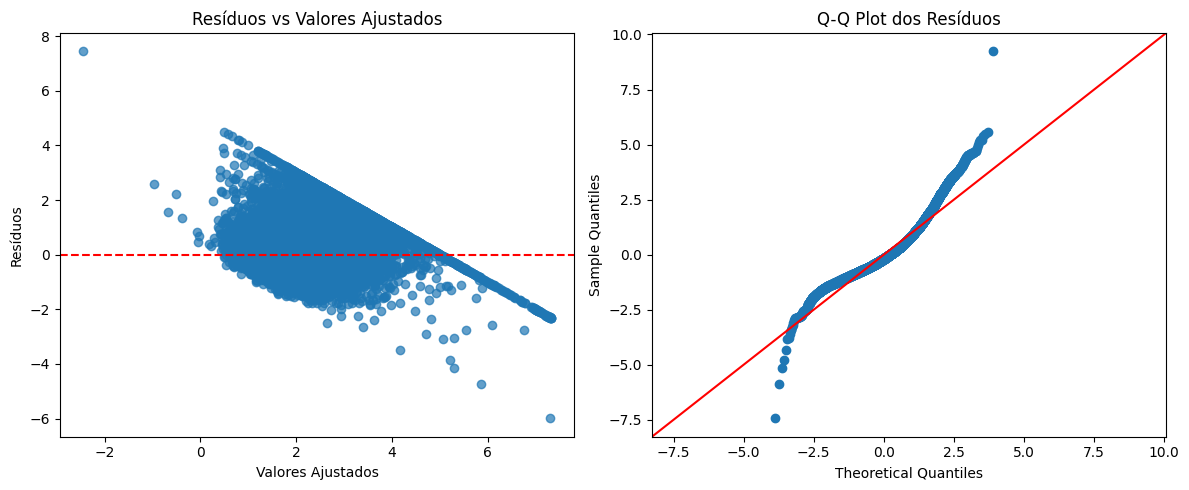

In [30]:
# Extraindo resíduos e valores ajustados
residuos = modelo_nivel_nivel.resid
valores_ajustados = modelo_nivel_nivel.fittedvalues

# Configurando o painel de diagnósticos visuais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Homocedasticidade: Resíduos vs Valores Ajustados
axes[0].scatter(valores_ajustados, residuos, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Resíduos vs Valores Ajustados')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Resíduos')

# 2. Normalidade: Q-Q Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

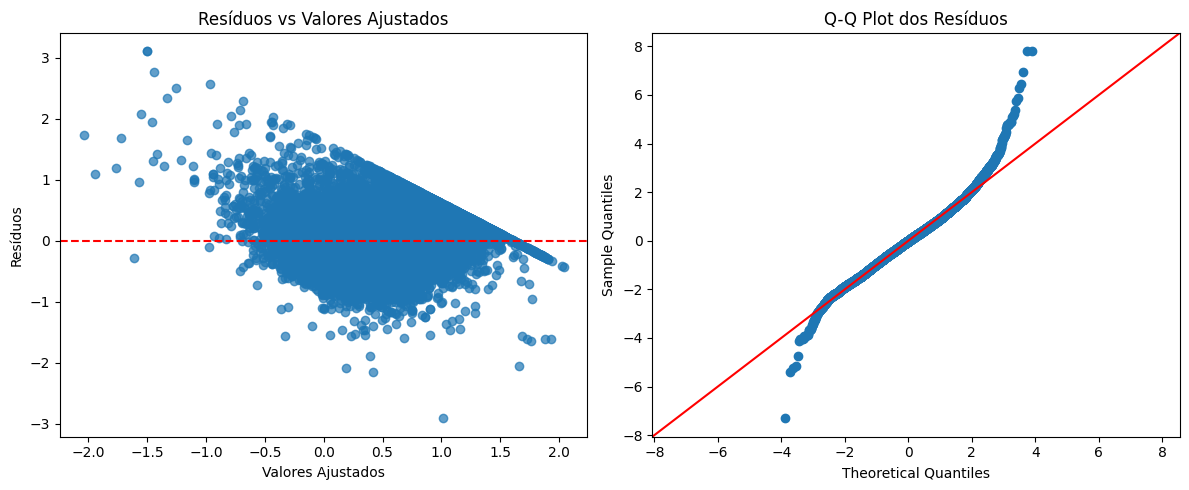

In [31]:
# Extraindo resíduos e valores ajustados
residuos = modelo_loglog.resid
valores_ajustados = modelo_loglog.fittedvalues

# Configurando o painel de diagnósticos visuais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Homocedasticidade: Resíduos vs Valores Ajustados
axes[0].scatter(valores_ajustados, residuos, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Resíduos vs Valores Ajustados')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Resíduos')

# 2. Normalidade: Q-Q Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

In [33]:
from scipy.stats import shapiro

# Teste de Normalidade de Shapiro-Wilk (H0: resíduos são normais)
stat_shapiro, p_shapiro = shapiro(residuos)
print(f'Shapiro-Wilk: p-valor = {p_shapiro:.4f}')

Shapiro-Wilk: p-valor = 0.0000


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20640.
  res = hypotest_fun_out(*samples, **kwds)


In [36]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Teste de Homocedasticidade de Breusch-Pagan (H0: resíduos são homocedásticos)
bp_test = het_breuschpagan(residuos, modelo.model.exog)
print(f'Breusch-Pagan: p-valor = {bp_test[1]:.4f}')

Breusch-Pagan: p-valor = 0.0000


In [49]:
from statsmodels.stats.diagnostic import linear_reset

# Implementar o teste RESET no modelo_nivel_nivel
# O argumento 'power' especifica o número de termos adicionados ao modelo
# (ex: power=2 para Y_hat^2)
reset_test = linear_reset(modelo_nivel_nivel, power=2)

print(reset_test.summary())
print(f'Teste RESET: p-valor = {reset_test.pvalue:.4f}')

<Wald test (chi2): statistic=222.17395554572033, p-value=3.0352802950808695e-50, df_denom=1>
Teste RESET: p-valor = 0.0000
